<a href="https://colab.research.google.com/github/lxndrkrln/laba_ML/blob/main/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа: Прогнозирование временного ряда
## Датасет: Jena Climate (температура)

In [1]:
!pip install gmdhpy

In [2]:
!apt-get install -y graphviz
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [3]:
!pip install gplearn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from gmdhpy import gmdh

In [5]:
df = pd.read_csv('JS.csv', parse_dates=['Date Time'])
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [6]:
df.shape

(420551, 15)

In [7]:
df = pd.read_csv('JS.csv', parse_dates=['Date Time'], dayfirst=True)
df = df.sort_values('Date Time').reset_index(drop=True)
df_daily = df.set_index('Date Time').resample('D').mean().dropna()
last_date = df_daily.index.max()
start_date = last_date - pd.DateOffset(years=3)
df_daily = df_daily[df_daily.index >= start_date]
df_daily.shape

(1095, 14)

In [9]:
ts = pd.DataFrame()
ts['T (degC)'] = df_daily['T (degC)']

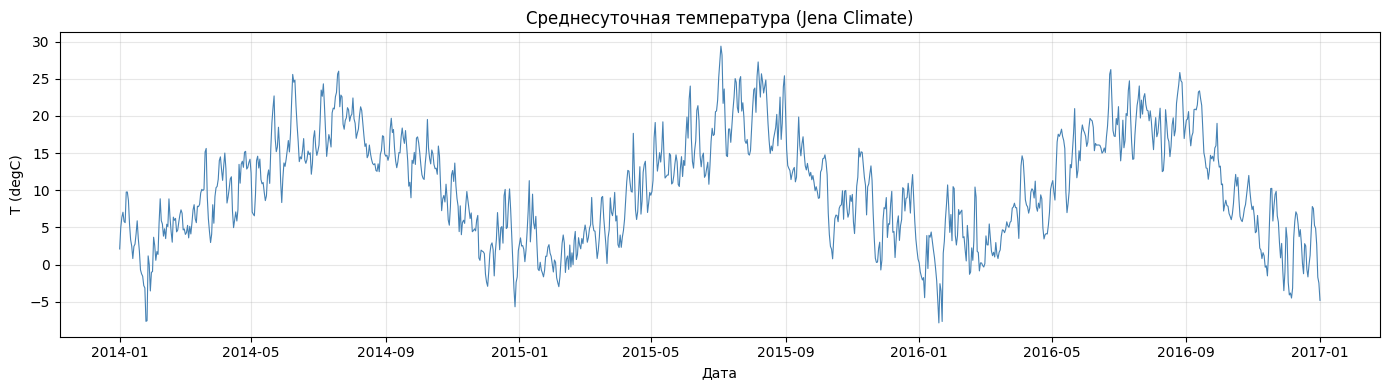

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts['T (degC)'].index, ts['T (degC)'].values, color='steelblue', linewidth=0.8)
ax.set_title('Среднесуточная температура (Jena Climate)')
ax.set_xlabel('Дата'); ax.set_ylabel('T (degC)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

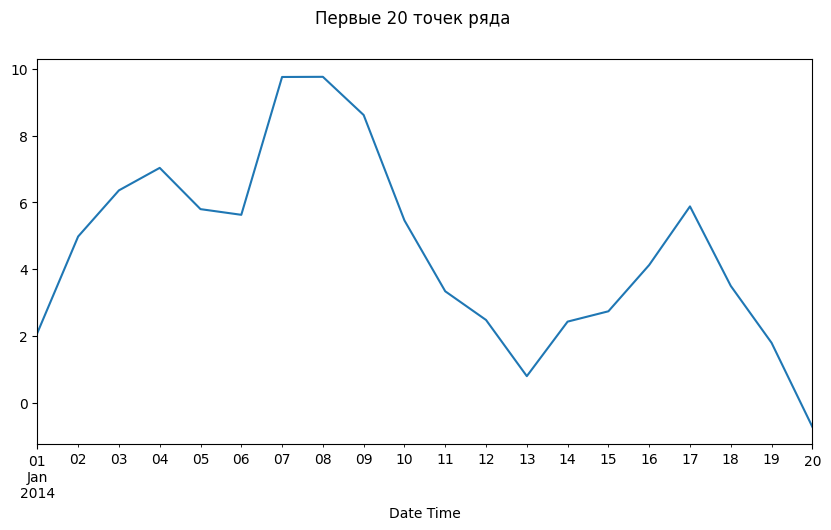

In [11]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Первые 20 точек ряда')
ts[:20].plot(ax=ax, legend=False)
plt.show()

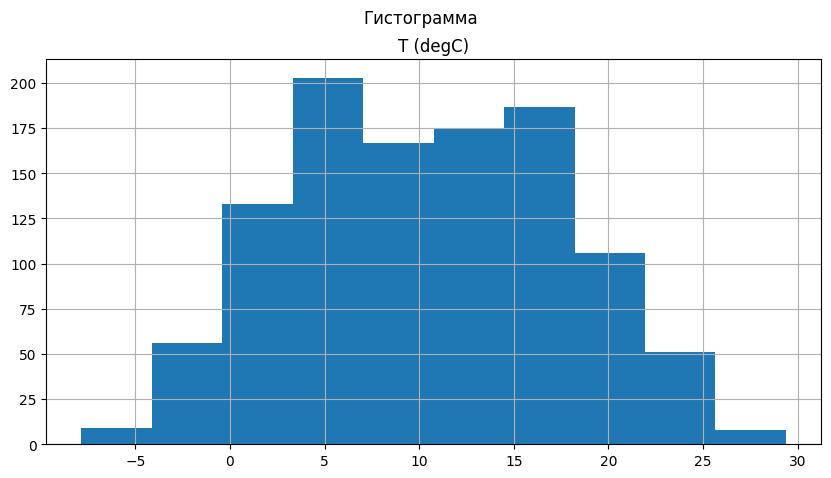

In [12]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Гистограмма')
ts.hist(ax=ax, legend=False)
plt.show()

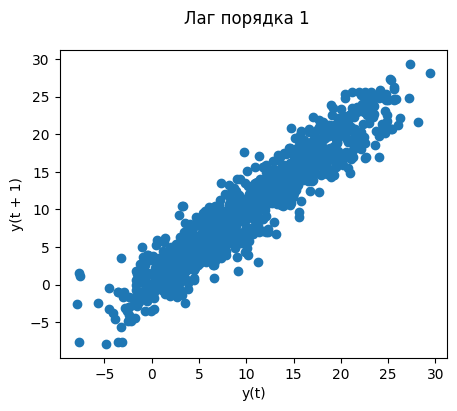

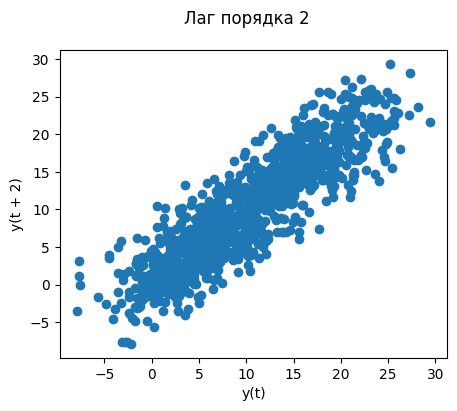

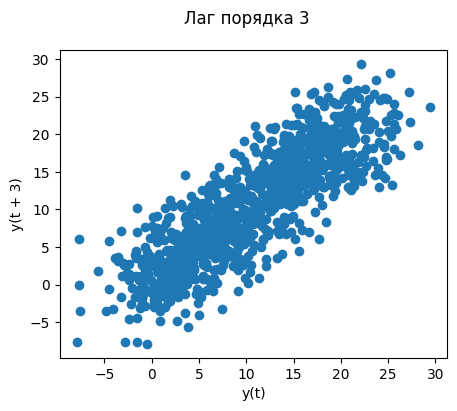

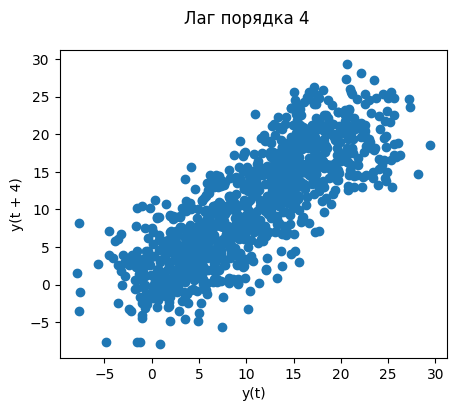

In [13]:
for i in range(1, 5):
    fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(5,4))
    fig.suptitle(f'Лаг порядка {i}')
    pd.plotting.lag_plot(ts, lag=i, ax=ax)
    plt.show()

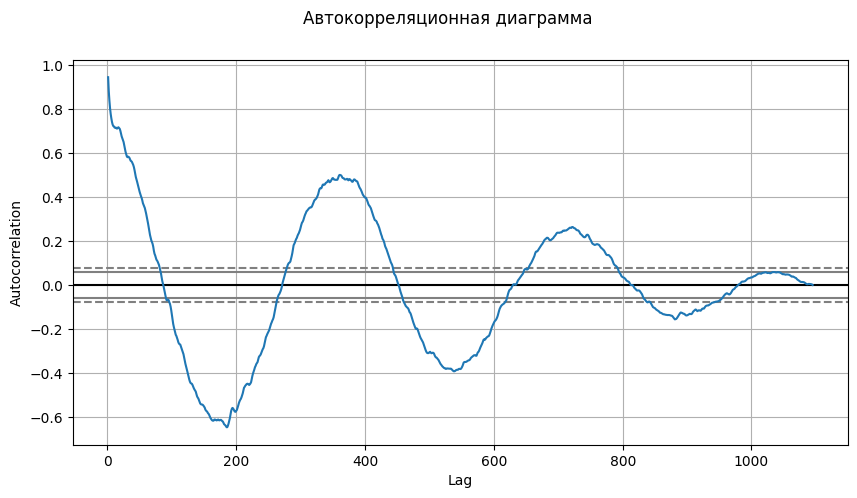

In [14]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Автокорреляционная диаграмма')
pd.plotting.autocorrelation_plot(ts, ax=ax)
plt.show()

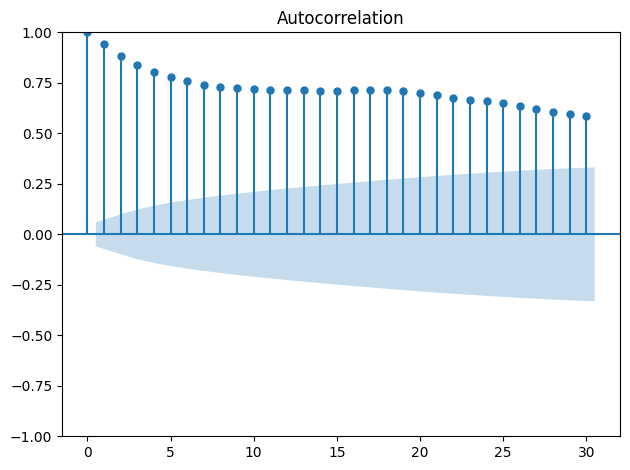

In [15]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(ts, lags=30)
plt.tight_layout()

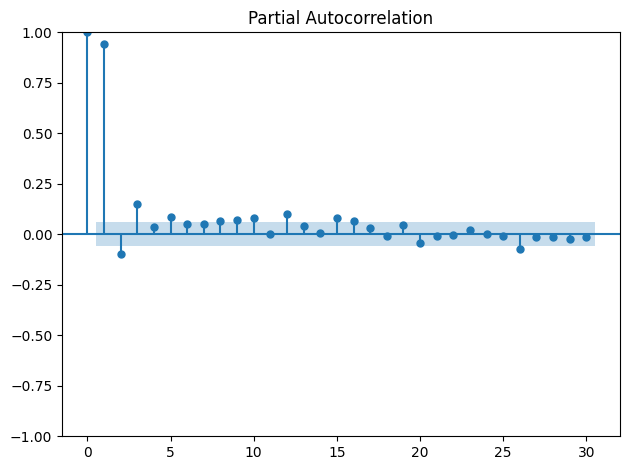

In [17]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(ts, lags=30)
plt.tight_layout()

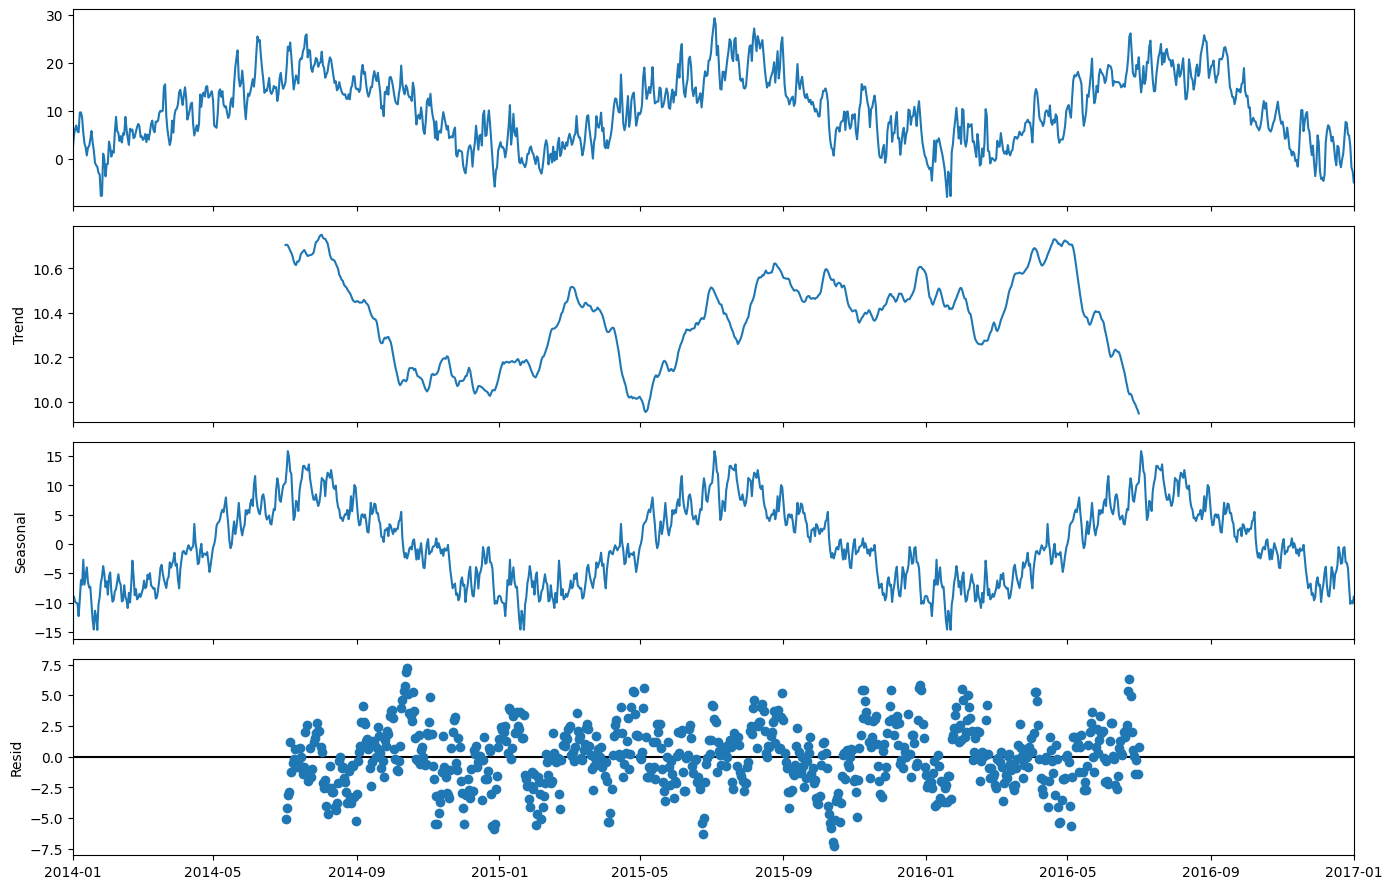

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(ts, model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(14, 9)
plt.tight_layout(); plt.show()

In [18]:
adf = adfuller(ts)
print(f'ADF статистика: {adf[0]:.4f}')
print(f'p-value: {adf[1]:.4f}')
print(f'Ряд {"стационарен" if adf[1] < 0.05 else "нестационарен"} (на уровне 0.05)')

ADF статистика: -1.9329
p-value: 0.3167
Ряд нестационарен (на уровне 0.05)


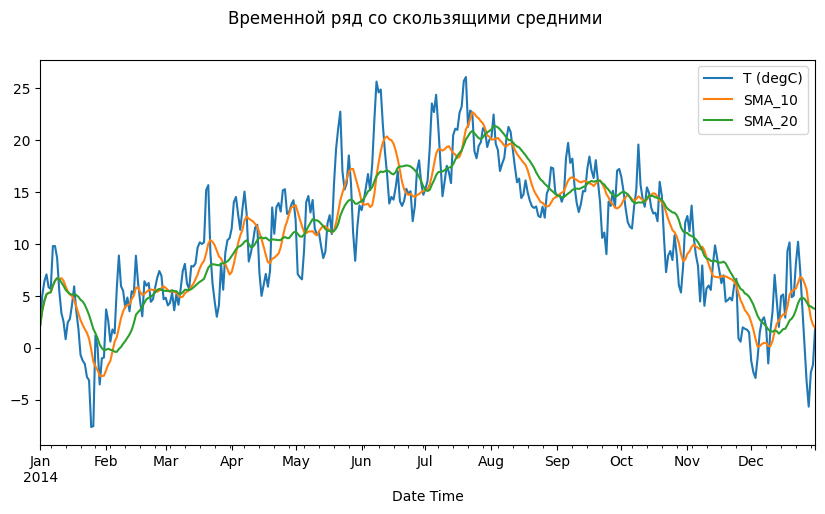

In [19]:
ts2 = ts.copy()

ts2['SMA_10'] = ts2['T (degC)'].rolling(window=10, min_periods=1).mean()
ts2['SMA_20'] = ts2['T (degC)'].rolling(window=20, min_periods=1).mean()
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд со скользящими средними')
ts2[:365].plot(ax=ax, legend=True)
plt.show()

In [20]:
xnum = list(range(ts.shape[0]))
Y = ts.values
train_size = int(len(Y) * 0.8)
xnum_train, xnum_test = xnum[0:train_size], xnum[train_size:]
train, test = Y[0:train_size], Y[train_size:]
history_arima = [x for x in train]
history_es = [x for x in train]

In [21]:
from statsmodels.tsa.arima.model import ARIMA
# Параметры модели (p,d,q)
arima_order = (6,1,0)
# Формирование предсказаний
predictions_arima = list()
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=arima_order)
    model_arima_fit = model_arima.fit()
    yhat_arima = model_arima_fit.forecast()[0]
    predictions_arima.append(yhat_arima)
    history_arima.append(test[t])
# Вычисление метрики MSE
error_arima = mean_squared_error(test, predictions_arima)

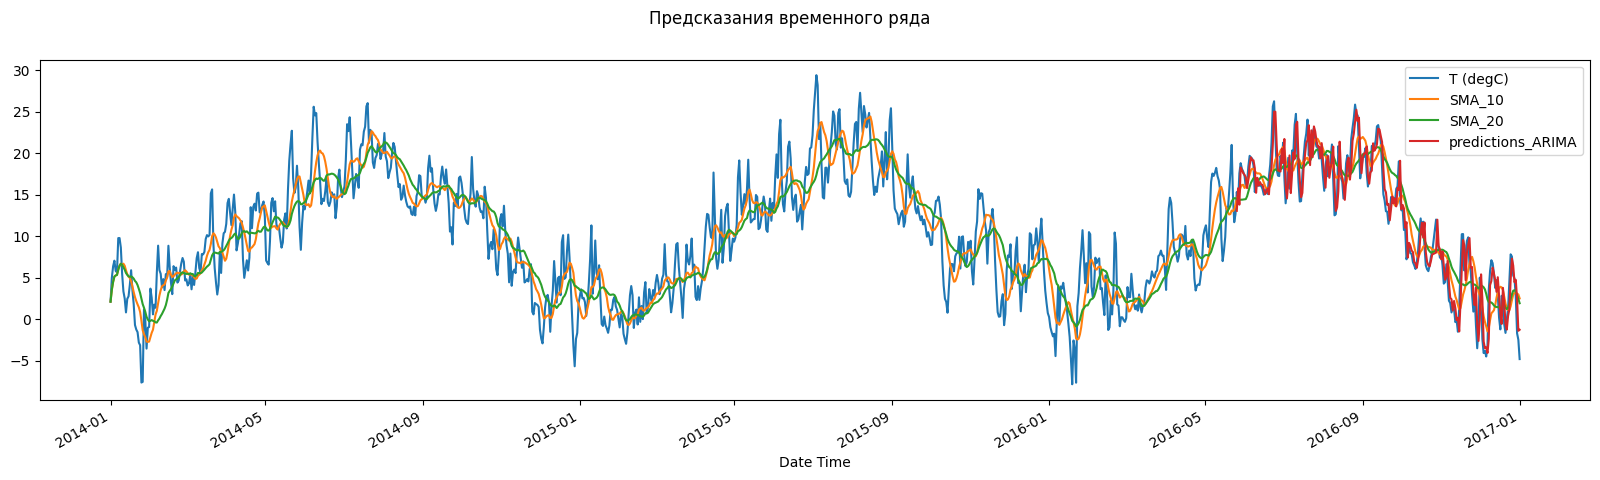

In [22]:
ts2['predictions_ARIMA'] = (train_size * [np.nan]) + list(predictions_arima)
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(20,5))
fig.suptitle('Предсказания временного ряда')
ts2.plot(ax=ax, legend=True)
plt.show()

In [23]:
from gplearn.genetic import SymbolicRegressor
function_set = ['add', 'sub', 'mul', 'div', 'sin']
est_gp = SymbolicRegressor(population_size=500, metric='mse',
                               generations=70, stopping_criteria=0.01,
                               init_depth=(4, 10), verbose=1, function_set=function_set,
                               const_range=(-100, 100), random_state=0)
est_gp.fit(np.array(xnum_train).reshape(-1, 1), train.reshape(-1, 1))
print(est_gp._program)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0   263.65      1.18612e+67      137          125.127              N/A      2.48m
   1   135.31      5.50725e+14       40           81.403              N/A      1.03m
   2   112.87      1.45324e+12        1          64.5432              N/A     54.76s
   3    48.59       7.5508e+11       39          49.3246              N/A     39.53s
   4    33.77      3.49415e+13       40          49.7152              N/A     33.50s
   5    26.07      4.31577e+14       29          47.9244              N/A     49.13s
   6    31.45      2.01475e+14       35          47.1862              N/A     49.22s
   7    34.12       1.9211e+14       12          45.4991              N/A     53.09s
   8    33.72      5.55932e+08       12          44.6726              N/A  

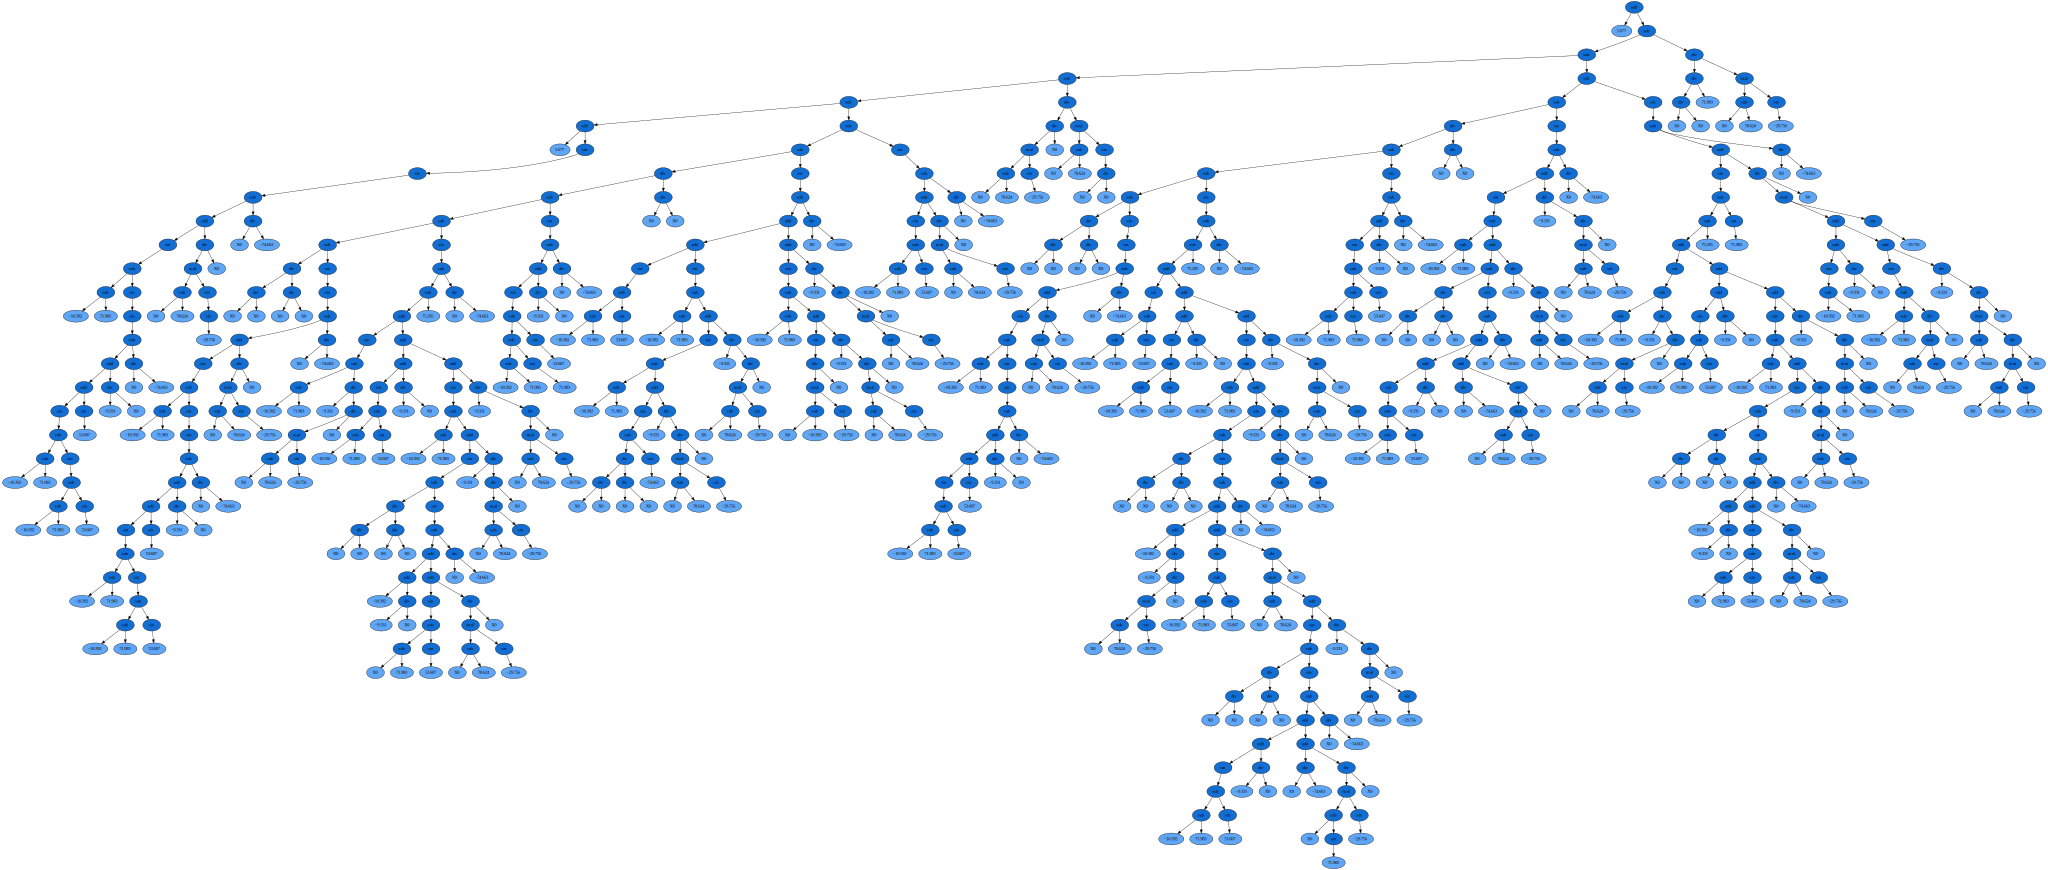

In [24]:
import graphviz
dot_data = est_gp._program.export_graphviz()
graph = graphviz.Source(dot_data)
graph